In [1]:
# ============================================================
# ECG Arrhythmia Classification using 1D CNN
# Model Training Notebook
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

print("=" * 50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("=" * 50)
print("All Libraries Imported Successfully ✅")

TensorFlow Version : 2.16.2
NumPy Version      : 1.24.3
All Libraries Imported Successfully ✅


In [2]:
# ============================================================
# Load Preprocessed Dataset
# ============================================================

X_train = np.load("../dataset/X_train.npy")
X_test  = np.load("../dataset/X_test.npy")

y_train = np.load("../dataset/y_train.npy")
y_test  = np.load("../dataset/y_test.npy")

print("=" * 50)
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

print()

print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

print("=" * 50)

Training Data Shape : (65926, 200)
Testing Data Shape  : (16482, 200)

Training Labels Shape : (65926,)
Testing Labels Shape  : (16482,)


In [3]:
# ============================================================
# Class Distribution
# ============================================================

print("Training Dataset")

print(pd.Series(y_train).value_counts())

print("\nTesting Dataset")

print(pd.Series(y_test).value_counts())

Training Dataset
1    58607
2     5282
0     2037
Name: count, dtype: int64

Testing Dataset
1    14652
2     1321
0      509
Name: count, dtype: int64


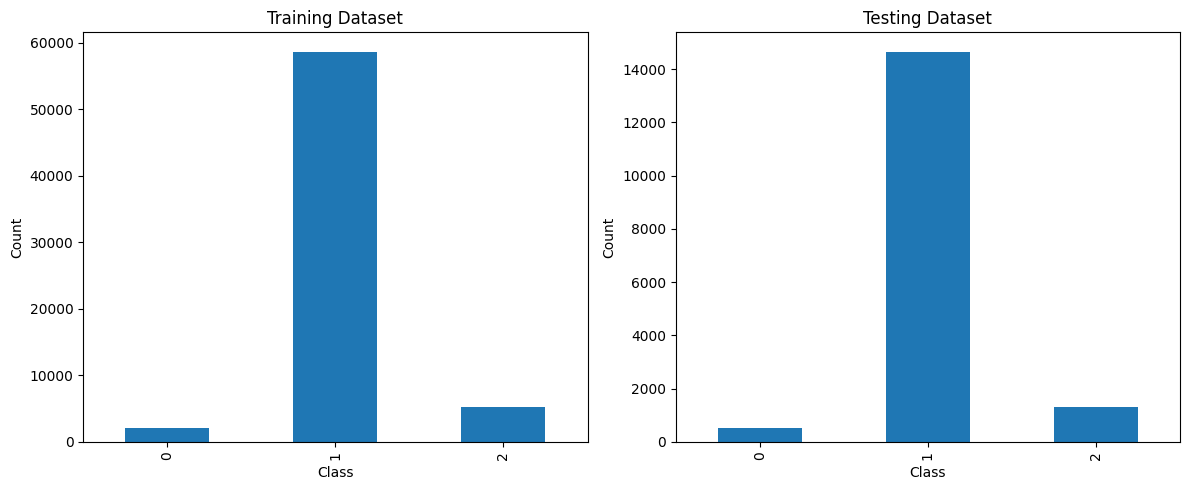

In [4]:
# ============================================================
# Train/Test Class Distribution
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(12,5))

pd.Series(y_train).value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0]
)

ax[0].set_title("Training Dataset")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

pd.Series(y_test).value_counts().sort_index().plot(
    kind="bar",
    ax=ax[1]
)

ax[1].set_title("Testing Dataset")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Count")

plt.tight_layout()

plt.show()

In [5]:
# ============================================================
# Reshape Dataset for CNN
# ============================================================

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("="*50)
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("="*50)

Training Shape : (65926, 200, 1)
Testing Shape  : (16482, 200, 1)


In [6]:
# ============================================================
# One-Hot Encoding
# ============================================================

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

print("="*50)
print("Training Labels :", y_train_cat.shape)
print("Testing Labels  :", y_test_cat.shape)
print("="*50)

Training Labels : (65926, 3)
Testing Labels  : (16482, 3)


In [7]:
print("Original Label :", y_train[:5])

print()

print("One Hot Labels")

print(y_train_cat[:5])

Original Label : [1 1 1 1 1]

One Hot Labels
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [8]:
# ============================================================
# Build 1D CNN Model
# ============================================================

model = Sequential([

    # Block 1
    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu",
        padding="same",
        input_shape=(200,1)
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.30),

    # Block 2
    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.30),

    # Block 3
    Conv1D(
        filters=256,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.40),

    Dense(
        3,
        activation="softmax"
    )

])

print("Model Created Successfully ✅")

Model Created Successfully ✅


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# ============================================================
# Compile Model
# ============================================================

model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("Model Compiled Successfully ✅")

Model Compiled Successfully ✅


In [10]:
# ============================================================
# Model Summary
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,723 (620.01 KB)

 Trainable params: 157,827 (616.51 KB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
# ============================================================
# Training Callbacks
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "arrhythmia_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks Ready ✅")

Callbacks Ready ✅


In [12]:
# ============================================================
# Calculate Class Weights
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 10.788087056128294, 1: 0.37496089773121527, 2: 4.160419033194497}


In [13]:
history = model.fit(

    X_train,
    y_train_cat,

    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=40,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    class_weight=class_weights,

    verbose=1
)

Epoch 1/40
1029/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6007 - loss: 0.7219
Epoch 1: val_accuracy improved from None to 0.81119, saving model to arrhythmia_cnn.keras

Epoch 1: finished saving model to arrhythmia_cnn.keras
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 37s 35ms/step - accuracy: 0.6702 - loss: 0.5981 - val_accuracy: 0.8112 - val_loss: 0.4347 - learning_rate: 0.0010
Epoch 2/40
1029/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7884 - loss: 0.4057
Epoch 2: val_accuracy did not improve from 0.81119
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.8028 - loss: 0.3896 - val_accuracy: 0.5652 - val_loss: 0.9889 - learning_rate: 0.0010
Epoch 3/40
1029/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8153 - loss: 0.3781
Epoch 3: val_accuracy improved from 0.81119 to 0.91918, saving model to arrhythmia_cnn.keras

Epoch 3: finished saving model to arrhythmia_cnn.keras
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.8457 - loss: 0.3374 - val_accuracy: 0.

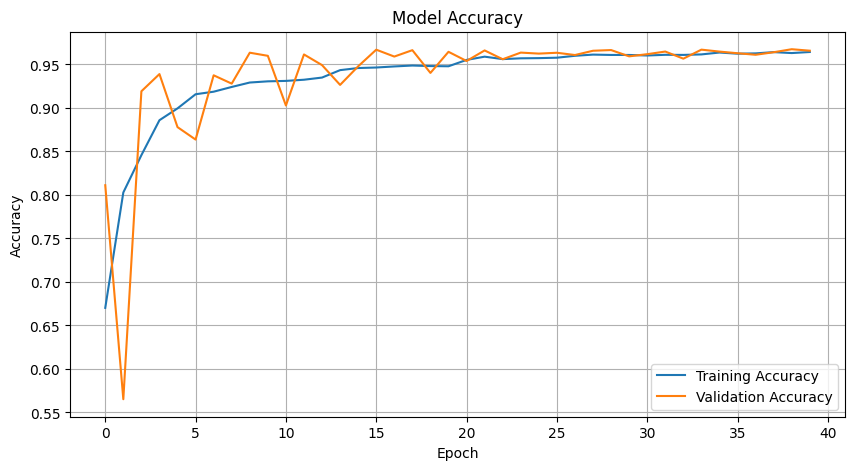

In [14]:
# ============================================================
# Accuracy Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

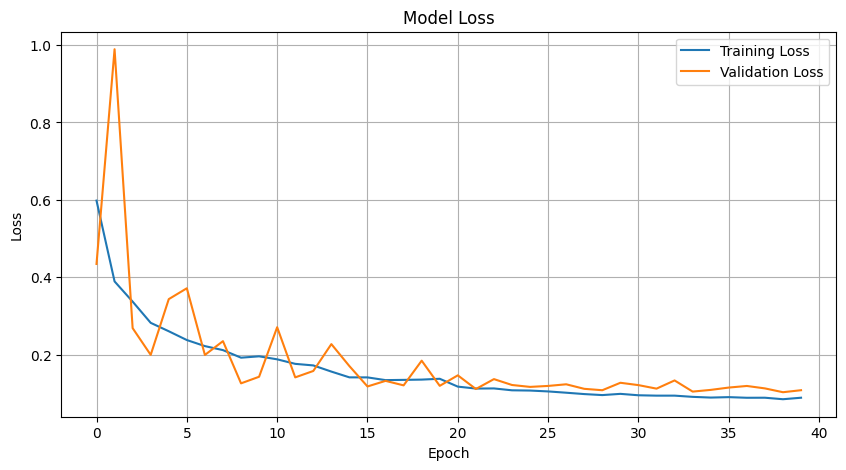

In [15]:
# ============================================================
# Loss Curve
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
# ============================================================
# Model Prediction
# ============================================================

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


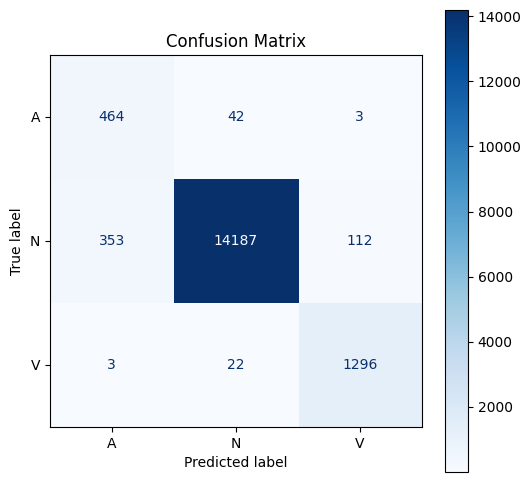

In [17]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A","N","V"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax, cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [18]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=["A","N","V"]
))

              precision    recall  f1-score   support

           A       0.57      0.91      0.70       509
           N       1.00      0.97      0.98     14652
           V       0.92      0.98      0.95      1321

    accuracy                           0.97     16482
   macro avg       0.83      0.95      0.88     16482
weighted avg       0.98      0.97      0.97     16482



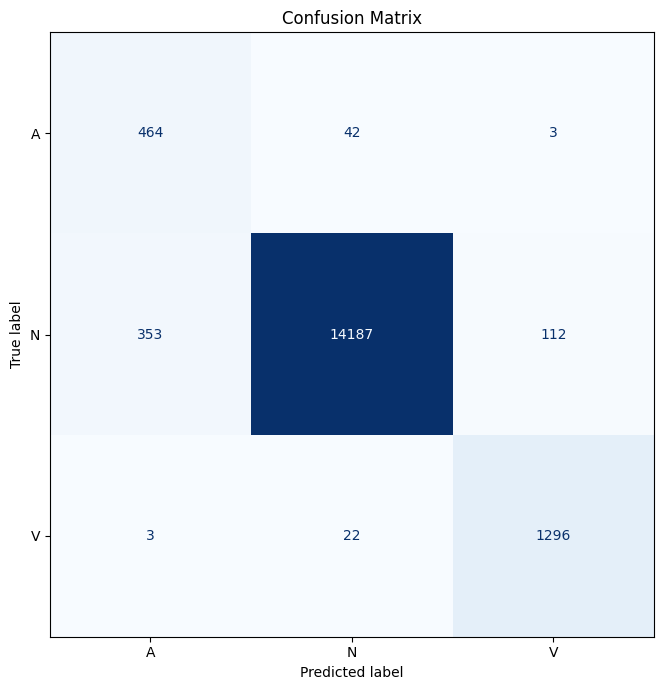

In [32]:
# ============================================================
# Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["A", "N", "V"]
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ============================================================
# ROC Curve Imports
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

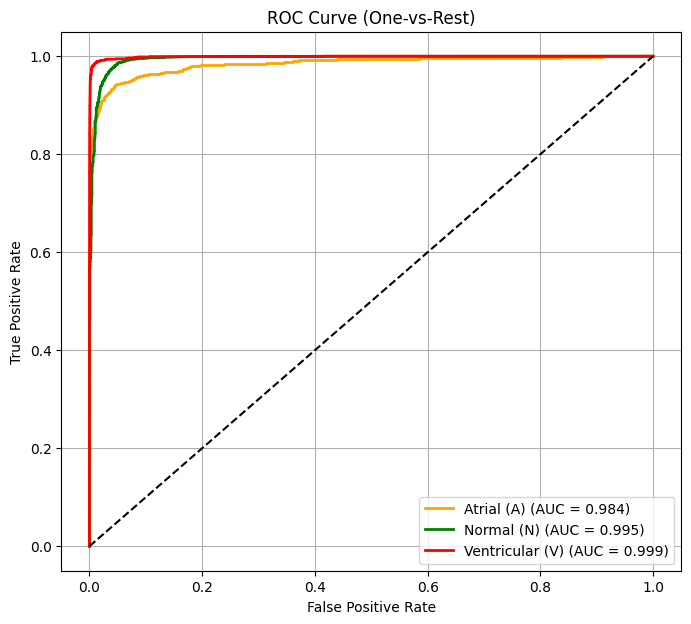

<Figure size 640x480 with 0 Axes>

In [28]:
# ============================================================
# ROC Curve (One-vs-Rest)
# ============================================================

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Predicted probabilities (already obtained from model.predict)
# y_pred contains probabilities

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,7))

colors = ["orange", "green", "red"]
labels = ["Atrial (A)", "Normal (N)", "Ventricular (V)"]

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        linewidth=2,
        label=f"{labels[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (One-vs-Rest)")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()
plt.tight_layout()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# ============================================================
# AUC Scores
# ============================================================

print("ROC-AUC Scores\n")

print(f"Atrial (A)       : {roc_auc[0]:.4f}")
print(f"Normal (N)       : {roc_auc[1]:.4f}")
print(f"Ventricular (V)  : {roc_auc[2]:.4f}")

ROC-AUC Scores

Atrial (A)       : 0.9844
Normal (N)       : 0.9946
Ventricular (V)  : 0.9989


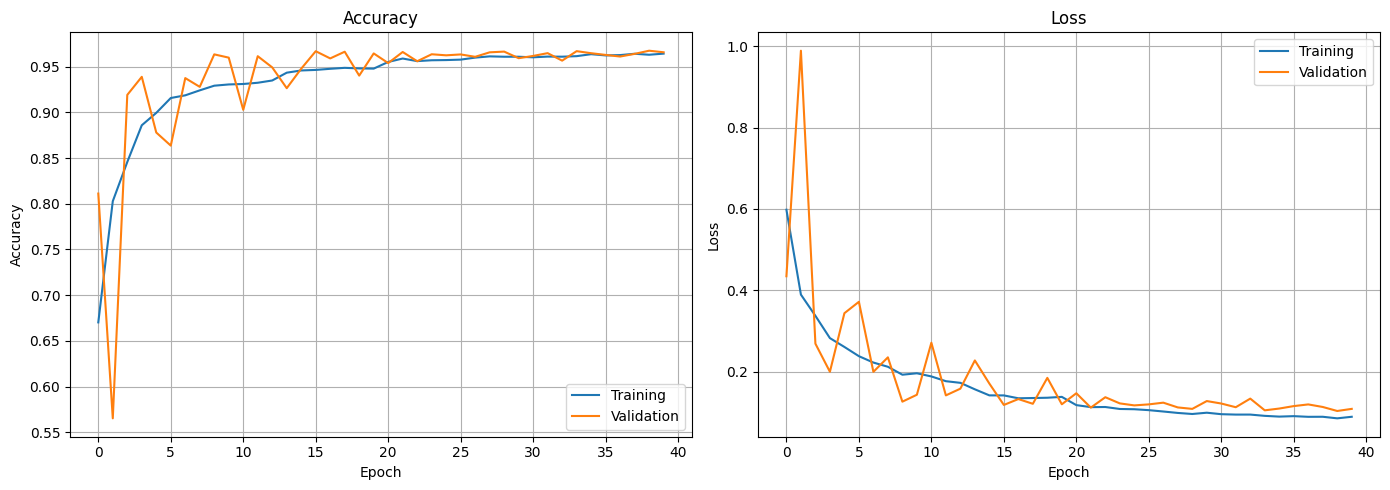

<Figure size 640x480 with 0 Axes>

In [26]:
# ============================================================
# Training History
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(14,5))

# Accuracy
ax[0].plot(history.history["accuracy"], label="Training")
ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history.history["loss"], label="Training")
ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig(
    "../images/training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
model.save("../models/ecg_arrhythmia_cnn.keras")

print("✅ Final Model Saved Successfully")

✅ Final Model Saved Successfully
